# Figure 2 — Tree Features ↔ Linear-Algebra Features (Flat CBM, non-balanced)

Empirical verification of three relations from Thesis V.03 across a $(\eta, m)$ grid
of **non-balanced** flat constant-block-model trees:

1.  $\mu(U) = (1+\eta)/2$ — coherence of the rank-2 subspace $U=[v^{(0)}, v^{(1)}]$.
2.  $\lambda_2 = m \cdot S_{\text{out}}^{\max}$ — Fiedler eigenvalue from cross-clan similarity.
3.  $\Delta\lambda \;\ge\; n_{\min}\rho - \eta\, n_{\min}\, S_{\text{out}}^{\max}$ — Lemma 0.4 spectral-gap lower bound.

**Sweep:** 
$$
\eta \in \{1, 2, 4, 8\} \ , \ m \in \{90, 180, \dots, 11520\}
$$ 
the same grid already cached on disk by `figure_3_nonbalanced_cbm_synthetic.ipynb`.\\
Each $S$ is loaded from `cache/theoretical_interpretation/full/`, so re-running this notebook is free.

## Cell 1 — Configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.theoretical_interpretation.utils import (
    build_decay_cbm_S, flat_cbm_population_fiedler,
    imbalance_eta, n_min as compute_n_min, structural_margin_rho,
    coherence_mu, compute_top_eigenpairs, spectral_gap,
    compute_recovery,
    compute_fiedler_of_S,
    make_full_key, get_or_compute_full,
)
from src.core.utils import compute_laplacian


# Within each clan, similarity decays geometrically with hierarchical TREE
# distance (recursive near-equal binary split):
#   S_ij = S_IN * ALPHA**dist(i, j)   (i, j same clan, i != j)
# where dist(i, j) is the merge-depth of the smallest subtree containing both
# leaves: siblings = 1, cousins = 2, ..., opposite halves of the clan root =
# ceil(log2(n_k)). Cross-clan entries stay constant at S_OUT. ALPHA = 1.0
# recovers the flat CBM verified previously; ALPHA < 1 introduces nested
# block structure inside each clan so we can see how the V.03 identities
# respond.
S_IN        = 0.9
S_OUT       = 0.05
ALPHA       = 0.99
ETA_VALUES  = [1, 2, 4, 8]
M_VALUES    = [90, 180, 360, 720, 1440, 2880, 5760]
CACHE_DIR   = PROJECT_ROOT / "cache" / "theoretical_interpretation"

# Maximum within-clan off-diagonal entry: sibling pairs at dist=1, so
#   max_{i!=j, same clan} S_IN * ALPHA**dist(i,j)  =  S_IN * ALPHA
S_IN_MAX_EFF = S_IN * ALPHA

print(f"S_in = {S_IN}, S_out = {S_OUT}, alpha = {ALPHA}")
print(f"effective S_in_max (= S_in*alpha) = {S_IN_MAX_EFF}")
print(f"eta values = {ETA_VALUES}")
print(f"m values   = {M_VALUES}")
print(f"cache_dir  = {CACHE_DIR}")


S_in = 0.9, S_out = 0.05, alpha = 0.99
effective S_in_max (= S_in*alpha) = 0.891
eta values = [1, 2, 4, 8]
m values   = [90, 180, 360, 720, 1440, 2880, 5760]
cache_dir  = /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/cache/theoretical_interpretation


## Cell 2 — Build $S$, Laplacian, and top-3 eigenpairs for each $(\eta, m)$ — cache-shared with Figure 3

For each $(\eta, m)$ we form $n_1 = m \mathbin{//} (1+\eta)$, $n_2 = m - n_1$ and load $S$
from the disk cache populated by Figure 3 (key:
`flat_cbm_eta..._n..._s_in0p9000_s_out0p0500`). The top-3 eigenpairs of $L = D - S$ are
recomputed locally — only $S$ itself is cached, since eigendecomposition is cheap relative
to matrix construction.

In [2]:
per_em = {}   # per_em[(eta, m)] = dict with S, L, eigvals, U, v1, n1, n2

build_summary = []
for eta in ETA_VALUES:
    for m in M_VALUES:
        n1 = m // (1 + int(eta))
        n2 = m - n1
        # Cache key prefix is "hier_cbm" so the new hierarchical decay matrices
        # don't collide with legacy "decay_cbm_*" caches written under the old
        # 1D-row-index decay semantics. alpha=1.0 still uses a dedicated key.
        full_key = make_full_key(
            "hier_cbm",
            eta=eta, n=m, s_in=S_IN, s_out=S_OUT, alpha=ALPHA,
        )

        def builder(n1=n1, n2=n2, full_key=full_key, eta=eta, m=m):
            S = build_decay_cbm_S(n1, n2, S_IN, S_OUT, alpha=ALPHA)
            fiedler_full = compute_fiedler_of_S(S)
            meta = {
                "tree_model": "hier_cbm",
                "eta": eta, "n1": n1, "n2": n2, "m": m,
                "s_in": S_IN, "s_out": S_OUT, "alpha": ALPHA,
                "full_key": full_key,
            }
            return S, fiedler_full, meta

        S, _ = get_or_compute_full(CACHE_DIR, full_key, builder)
        L = compute_laplacian(S)
        eigvals, eigvecs = compute_top_eigenpairs(L, k=3)
        per_em[(eta, m)] = {
            "S": S,
            "L": L,
            "eigvals": eigvals,             # λ_1, λ_2, λ_3 ascending
            "U": eigvecs[:, :2],            # [v^(0), v^(1)]
            "v1": eigvecs[:, 1],            # empirical Fiedler
            "n1": n1, "n2": n2,
        }
        build_summary.append({
            "eta": eta, "m": m, "n1": n1, "n2": n2,
            "lambda_2": float(eigvals[1]), "lambda_3": float(eigvals[2]),
        })

pd.DataFrame(build_summary)


,eta,m,n1,n2,lambda_2,lambda_3
0,1,90,45,45,4.499978,40.379906
1,1,180,90,90,9.000172,79.997330
2,1,360,180,180,18.000288,158.484665
3,1,720,360,360,35.997791,313.975128
4,1,1440,720,720,71.995445,622.030701
5,1,2880,1440,1440,144.029739,1232.352417
6,1,5760,2880,2880,288.090088,2441.539795
7,2,90,30,60,4.499966,28.676682
8,2,180,60,120,8.999962,56.839836
9,2,360,120,240,18.000566,112.663857


## Cell 3 — Representative similarity matrix $S$ (heatmap)

A single $S$ rendered for $\eta=4$, $m=360$ to make the constant-block-model structure
visible: a $C_1\times C_1$ block at $S_{\mathrm{in}}$, a $C_2\times C_2$ block at
$S_{\mathrm{in}}$, and the asymmetric off-diagonal blocks at $S_{\mathrm{out}}$. White
lines mark the $n_1$ boundary.

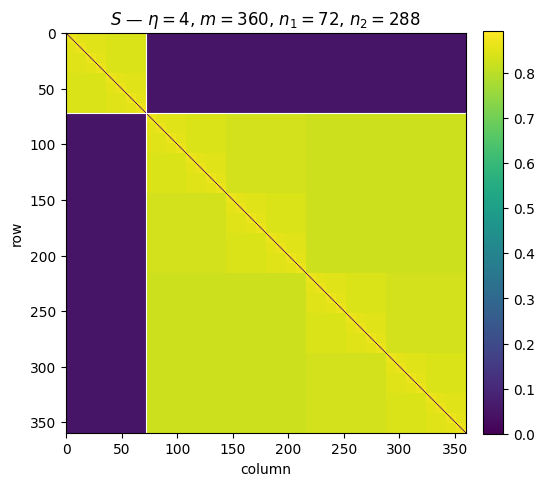

In [3]:
# One representative similarity matrix S — eta=4, m=360 (mid-range imbalance,
# size large enough to read the block structure, small enough to render crisply).
HEATMAP_ETA = 4
HEATMAP_M   = 360
entry = per_em[(HEATMAP_ETA, HEATMAP_M)]
S_show = entry["S"]
n1     = entry["n1"]
n2     = entry["n2"]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(S_show, cmap="viridis", aspect="equal")
# Block boundaries
ax.axhline(n1 - 0.5, color="white", lw=0.8)
ax.axvline(n1 - 0.5, color="white", lw=0.8)
ax.set_title(fr"$S$ — $\eta={HEATMAP_ETA}$, $m={HEATMAP_M}$, $n_1={n1}$, $n_2={n2}$")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Cell 4 — Sanity: empirical $v^{(1)}$ matches the closed-form flat-CBM Fiedler

Sign-agreement should be $1.0$ (eigh sign convention is arbitrary, so
`compute_recovery` accounts for the global sign) and the magnitude error
$\big\| |v_{\text{emp}}| - |v_{\text{closed}}| \big\|_\infty$ should be at
machine precision.

In [4]:
sanity_rows = []
for eta in ETA_VALUES:
    for m in M_VALUES:
        entry    = per_em[(eta, m)]
        n1, n2   = entry["n1"], entry["n2"]
        v_emp    = entry["v1"]
        v_closed = flat_cbm_population_fiedler(n1, n2)
        # Align global sign: eigh returns ±v with arbitrary sign.
        sign     = float(np.sign(np.dot(v_emp, v_closed)) or 1.0)
        v_emp_aligned = sign * v_emp
        agreement = compute_recovery(v_closed, v_emp_aligned)
        mag_err   = float(np.max(np.abs(np.abs(v_emp) - np.abs(v_closed))))
        sanity_rows.append({
            "eta": eta, "m": m, "n1": n1, "n2": n2,
            "agreement": agreement, "magnitude_inf_err": mag_err,
        })

df_sanity = pd.DataFrame(sanity_rows)
df_sanity

,eta,m,n1,n2,agreement,magnitude_inf_err
0,1,90,45,45,1.0,4.264581e-07
1,1,180,90,90,1.0,1.183051e-06
2,1,360,180,180,1.0,8.149511e-07
3,1,720,360,360,1.0,2.476523e-06
4,1,1440,720,720,1.0,1.739267e-06
5,1,2880,1440,1440,1.0,4.770632e-06
6,1,5760,2880,2880,1.0,2.936682e-06
7,2,90,30,60,1.0,5.779632e-07
8,2,180,60,120,1.0,6.687773e-07
9,2,360,120,240,1.0,1.046011e-06


## Cell 5 — Compute tree- and linear-algebra-side features per $(\eta, m)$

Columns:

* tree-side: $\eta,\; n_{\min},\; \rho$
* linear-algebra-side: $\mu_{\text{emp}},\; \lambda_{2,\text{emp}},\; \Delta\lambda_{\text{emp}}$
* predictions / bound: $\mu_{\text{pred}}=(1+\eta)/2,\; \lambda_{2,\text{pred}}=m\cdot S_{\text{out}},\; \Delta\lambda_{\text{LB}} = n_{\min}\rho - \eta n_{\min} S_{\text{out}}$

In [5]:
rows = []
for eta_target in ETA_VALUES:
    for m in M_VALUES:
        entry  = per_em[(eta_target, m)]
        n1, n2 = entry["n1"], entry["n2"]
        eta    = imbalance_eta(n1, n2)
        nmin   = compute_n_min(n1, n2)
        # Under geometric decay, the V.03 identities use the *max* off-diagonal
        # within-clan entry, which is S_IN*ALPHA (at |i-j|=1). Cross-clan entries
        # are still constant, so S_out_min = S_out_max = S_OUT.
        rho    = structural_margin_rho(S_IN_MAX_EFF, S_OUT, S_OUT)

        eigvals = entry["eigvals"]
        U       = entry["U"]

        mu_emp        = coherence_mu(U)
        lambda2_emp   = float(eigvals[1])
        gap_emp       = spectral_gap(eigvals)

        mu_pred       = (1.0 + eta) / 2.0
        lambda2_pred  = m * S_OUT
        gap_lb        = nmin * rho - eta * nmin * S_OUT

        rows.append({
            "eta": eta, "m": m, "n1": n1, "n2": n2, "n_min": nmin, "rho": rho,
            "mu_emp": mu_emp,         "mu_pred": mu_pred,
            "lambda2_emp": lambda2_emp, "lambda2_pred": lambda2_pred,
            "gap_emp": gap_emp,       "gap_lb": gap_lb,
            "mu_residual":      mu_emp - mu_pred,
            "lambda2_residual": lambda2_emp - lambda2_pred,
            "gap_slack":        gap_emp - gap_lb,
        })

df = pd.DataFrame(rows)
df


,eta,m,n1,n2,n_min,rho,mu_emp,mu_pred,lambda2_emp,lambda2_pred,gap_emp,gap_lb,mu_residual,lambda2_residual,gap_slack
0,1.0,90,45,45,45,0.841,1.000001,1.0,4.499978,4.5,35.879929,35.595,5.960464e-07,-0.000022,0.284929
1,1.0,180,90,90,90,0.841,1.000002,1.0,9.000172,9.0,70.997162,71.190,1.668930e-06,0.000172,-0.192838
2,1.0,360,180,180,180,0.841,1.000003,1.0,18.000288,18.0,140.484375,142.380,3.099442e-06,0.000288,-1.895625
3,1.0,720,360,360,360,0.841,1.000003,1.0,35.997791,36.0,277.977325,284.760,3.099442e-06,-0.002209,-6.782675
4,1.0,1440,720,720,720,0.841,1.000008,1.0,71.995445,72.0,550.035278,569.520,8.463860e-06,-0.004555,-19.484722
5,1.0,2880,1440,1440,1440,0.841,1.000020,1.0,144.029739,144.0,1088.322632,1139.040,1.990795e-05,0.029739,-50.717368
6,1.0,5760,2880,2880,2880,0.841,1.000035,1.0,288.090088,288.0,2153.449707,2278.080,3.528595e-05,0.090088,-124.630293
7,2.0,90,30,60,30,0.841,1.500000,1.5,4.499966,4.5,24.176716,22.230,3.576279e-07,-0.000034,1.946716
8,2.0,180,60,120,60,0.841,1.500001,1.5,8.999962,9.0,47.839874,44.460,5.960464e-07,-0.000038,3.379874
9,2.0,360,120,240,120,0.841,1.500001,1.5,18.000566,18.0,94.663292,88.920,1.072884e-06,0.000566,5.743292


## Cell 6 — Three-panel verification figure (identity-line scatter)

Each panel plots predicted vs empirical across all $(\eta, m)$ pairs, colored by $\eta$.
A $y = x$ line marks exact agreement; for the spectral-gap panel the inequality means
points should lie **on or above** the line.


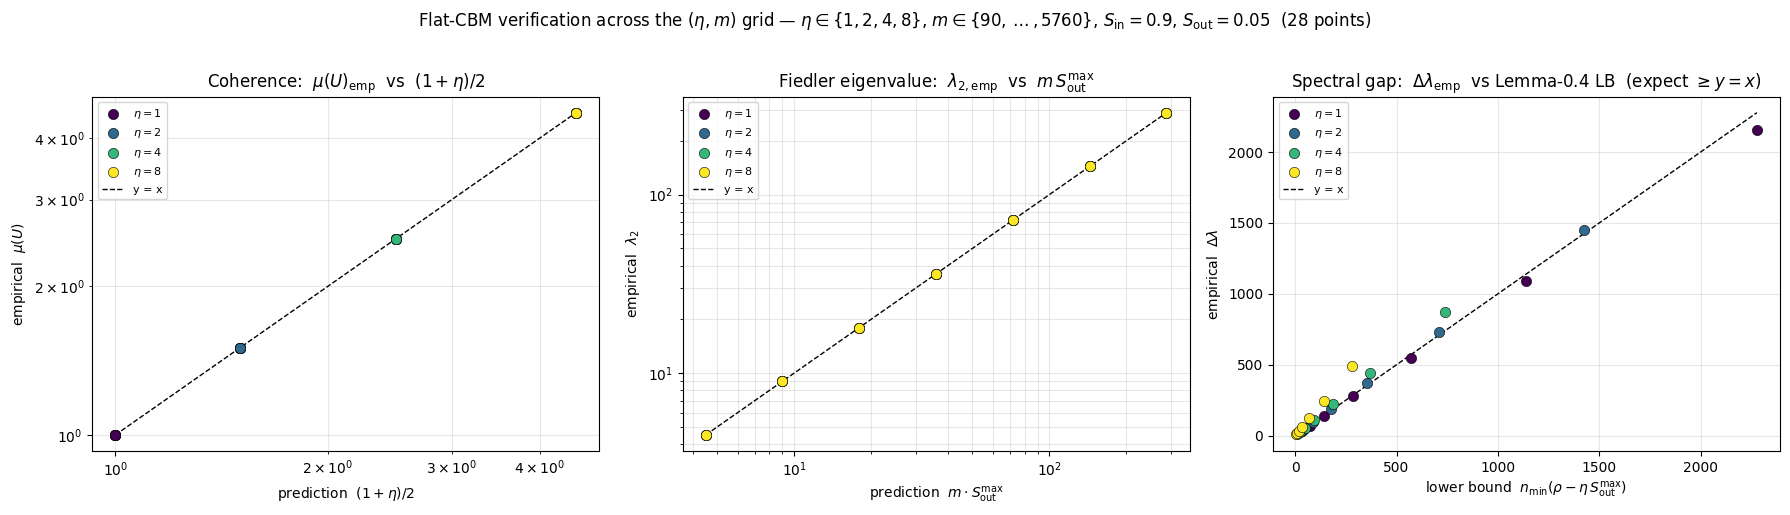

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmap = plt.get_cmap("viridis")
eta_to_color = {eta: cmap(i / max(1, len(ETA_VALUES) - 1)) for i, eta in enumerate(ETA_VALUES)}


def _identity_scatter(ax, x_col, y_col, *, log=False):
    for eta in ETA_VALUES:
        sub = df[df["eta"] == eta]
        ax.scatter(sub[x_col], sub[y_col], s=55, color=eta_to_color[eta],
                   edgecolors="k", linewidths=0.4, label=fr"$\eta={int(eta)}$", zorder=3)
    lo = float(min(df[x_col].min(), df[y_col].min()))
    hi = float(max(df[x_col].max(), df[y_col].max()))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    if log:
        ax.set_xscale("log"); ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)


# Each panel: empirical (y) vs theoretical prediction / bound (x), one point per (eta, m).
# A point on y=x means the relation holds exactly; for the spectral-gap panel the
# inequality means points should sit ON OR ABOVE the line.

# Left: empirical μ(U) vs prediction (1+η)/2
ax = axes[0]
_identity_scatter(ax, "mu_pred", "mu_emp", log=True)
ax.set_xlabel(r"prediction  $(1+\eta)/2$")
ax.set_ylabel(r"empirical  $\mu(U)$")
ax.set_title(r"Coherence:  $\mu(U)_{\mathrm{emp}}$  vs  $(1+\eta)/2$")
ax.legend(fontsize=8)

# Middle: empirical λ_2 vs prediction m·S_out
ax = axes[1]
_identity_scatter(ax, "lambda2_pred", "lambda2_emp", log=True)
ax.set_xlabel(r"prediction  $m \cdot S_{\mathrm{out}}^{\max}$")
ax.set_ylabel(r"empirical  $\lambda_2$")
ax.set_title(r"Fiedler eigenvalue:  $\lambda_{2,\mathrm{emp}}$  vs  $m\, S_{\mathrm{out}}^{\max}$")
ax.legend(fontsize=8)

# Right: empirical Δλ vs lower bound n_min(ρ − η·S_out) — points should be ON OR ABOVE y=x
ax = axes[2]
_identity_scatter(ax, "gap_lb", "gap_emp", log=False)
ax.set_xlabel(r"lower bound  $n_{\min}(\rho - \eta\, S_{\mathrm{out}}^{\max})$")
ax.set_ylabel(r"empirical  $\Delta\lambda$")
ax.set_title(r"Spectral gap:  $\Delta\lambda_{\mathrm{emp}}$  vs Lemma-0.4 LB  (expect $\geq y{=}x$)")
ax.legend(fontsize=8)

fig.suptitle(
    fr"Flat-CBM verification across the $(\eta, m)$ grid "
    fr"— $\eta\in\{{1,2,4,8\}}$, $m\in\{{{min(M_VALUES)},\dots,{max(M_VALUES)}\}}$, "
    fr"$S_{{\mathrm{{in}}}}={S_IN}$, $S_{{\mathrm{{out}}}}={S_OUT}$  ({len(df)} points)",
    y=1.02,
)
fig.tight_layout()
plt.show()

## Cell 7 — Spectral gap & lower bound vs $\eta$ (at fixed $m$)

Original "two curves vs $\eta$" framing of Lemma 0.4, now with **one (empirical $\Delta\lambda$, lower bound) pair per $\alpha$** overlaid in the same panel. Each color is one $\alpha$; solid is empirical, dashed is the bound.

For $\alpha=1$ (flat CBM) the empirical curve sits at-or-above the dashed bound at every $\eta$. As $\alpha$ shrinks the empirical $\Delta\lambda$ collapses (within-clan decay introduces extra eigenmodes between $\lambda_2$ and $\lambda_3$), while the bound — which only sees the new $S_{\text{in}}^{\max} = S_{\text{in}}\cdot\alpha$ — barely moves. The gap between the curves at the same $\alpha$ is the Lemma-0.4 slack; when the solid line dips below the dashed one, the bound is violated.

Change `GAP_VS_ETA_M` or `GAP_VS_ETA_ALPHAS` in the cell to inspect different sizes / decay rates.

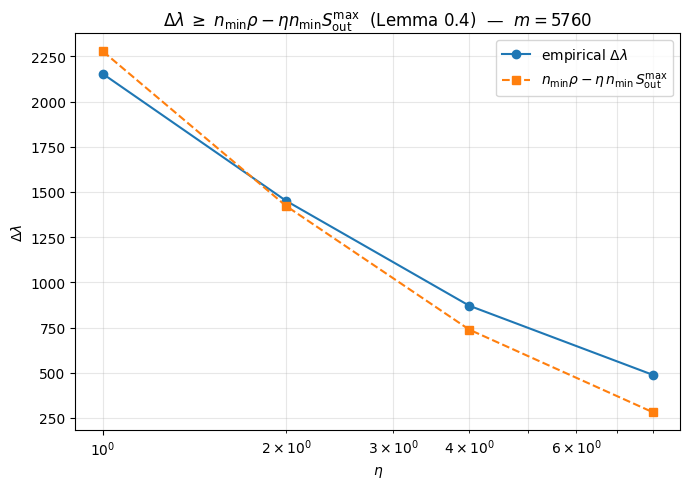

In [7]:
# Same Lemma-0.4 relation as the right panel of Cell 6, but in the original
# "two curves vs eta" style: fix m, plot empirical Δλ and the bound
# n_min(ρ − η·S_out^max) as functions of eta on log-x.
GAP_VS_ETA_M = max(M_VALUES)   # change to inspect a different total size

sub = df[df["m"] == GAP_VS_ETA_M].sort_values("eta")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sub["eta"], sub["gap_emp"], "-o", color="C0",
        label=r"empirical $\Delta\lambda$")
ax.plot(sub["eta"], sub["gap_lb"],  "--s", color="C1",
        label=r"$n_{\min}\rho - \eta\, n_{\min}\, S_{\mathrm{out}}^{\max}$")
ax.set_xscale("log")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\Delta\lambda$")
ax.set_title(
    fr"$\Delta\lambda \;\geq\; n_{{\min}}\rho - \eta n_{{\min}} S_{{\mathrm{{out}}}}^{{\max}}$  "
    fr"(Lemma 0.4)  —  $m={GAP_VS_ETA_M}$"
)
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()


## Cell 8 — Residual / slack summary

In [8]:
print("max |μ_emp − (1+η)/2|        =", float(df["mu_residual"].abs().max()))
print("max |λ_2,emp − m·S_out|     =", float(df["lambda2_residual"].abs().max()))
print("min Δλ_emp − bound          =", float(df["gap_slack"].min()))
print()
print(df[["eta", "m", "n1", "n2", "n_min", "rho",
         "mu_emp", "mu_pred",
         "lambda2_emp", "lambda2_pred",
         "gap_emp", "gap_lb", "gap_slack"]].to_string(index=False))

max |μ_emp − (1+η)/2|        = 5.817413330078125e-05
max |λ_2,emp − m·S_out|     = 0.1552734375
min Δλ_emp − bound          = -124.63029296874993

 eta    m   n1   n2  n_min   rho   mu_emp  mu_pred  lambda2_emp  lambda2_pred     gap_emp   gap_lb   gap_slack
 1.0   90   45   45     45 0.841 1.000001      1.0     4.499978           4.5   35.879929   35.595    0.284929
 1.0  180   90   90     90 0.841 1.000002      1.0     9.000172           9.0   70.997162   71.190   -0.192838
 1.0  360  180  180    180 0.841 1.000003      1.0    18.000288          18.0  140.484375  142.380   -1.895625
 1.0  720  360  360    360 0.841 1.000003      1.0    35.997791          36.0  277.977325  284.760   -6.782675
 1.0 1440  720  720    720 0.841 1.000008      1.0    71.995445          72.0  550.035278  569.520  -19.484722
 1.0 2880 1440 1440   1440 0.841 1.000020      1.0   144.029739         144.0 1088.322632 1139.040  -50.717368
 1.0 5760 2880 2880   2880 0.841 1.000035      1.0   288.090088         288.

## Cell 9 — How $\alpha$ "breaks" the V.03 identities (S heatmaps + spectral diagnostics)

Same $(\eta, m, S_{\text{in}}, S_{\text{out}})$ — only $\alpha$ varies across $\{1.0, 0.99, 0.95\}$.
$\alpha=1$ is the original flat CBM where every identity holds. The heatmaps make
the within-clan banding visible, and the table underneath shows how the three V.03
relations degrade row-by-row:

- $\mu_{\text{residual}} = \mu(U) - (1+\eta)/2$
- $\lambda_2 - n\,S_{\text{out}}^{\max}$
- $\Delta\lambda - \text{gap\_lb}$ (Lemma 0.4 slack — should be $\ge 0$)


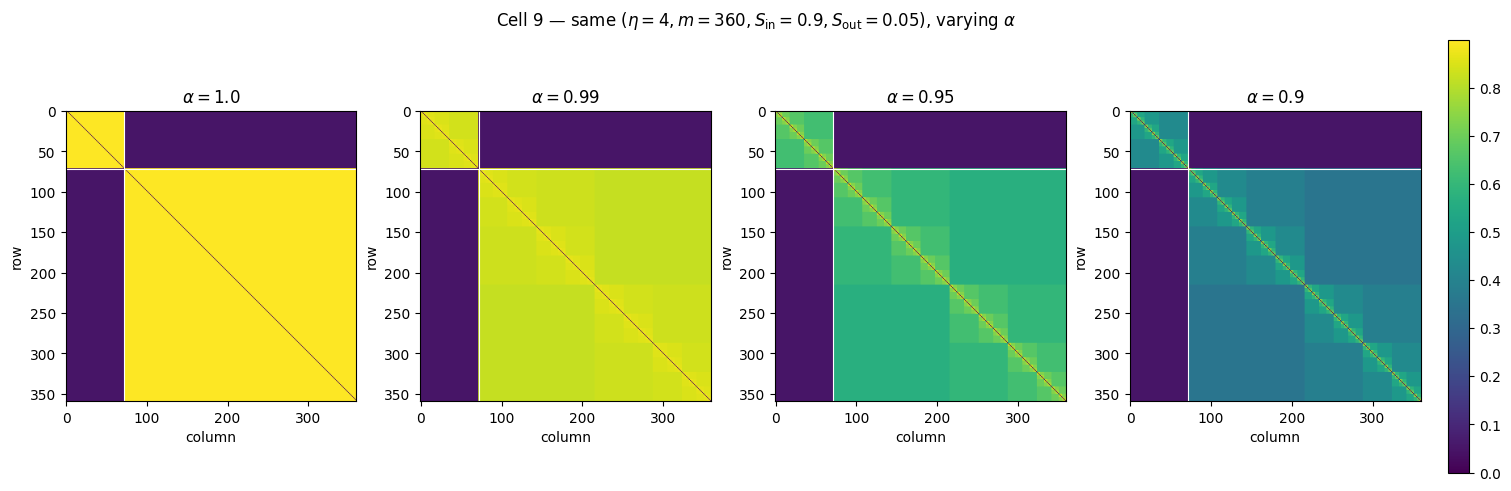

,rho,mu_emp,mu_pred,mu_residual,lambda2,lambda2_pred,lambda2_residual,delta_lambda,gap_lb,gap_slack
alpha,,,,,,,,,,
1.00,0.850,2.500000,2.5,-2.384186e-07,18.000589,18.0,0.000589,61.200333,46.800,14.400333
0.99,0.841,2.500001,2.5,9.536743e-07,18.000414,18.0,0.000414,56.798027,46.152,10.646027
0.95,0.805,2.500003,2.5,3.099442e-06,17.999819,18.0,-0.000181,41.652206,43.560,-1.907794
0.90,0.760,2.500002,2.5,2.145767e-06,17.999819,18.0,-0.000181,27.393602,40.320,-12.926398


In [13]:
# Hold (eta, m, S_in, S_out) fixed and sweep alpha.
DEMO_ETA  = 4
DEMO_M    = 360
ALPHAS_DEMO = [1.0, 0.99, 0.95, 0.90]

n1_demo = DEMO_M // (1 + int(DEMO_ETA))
n2_demo = DEMO_M - n1_demo
eta_demo  = imbalance_eta(n1_demo, n2_demo)
nmin_demo = compute_n_min(n1_demo, n2_demo)

# Build S, top-3 eigenpairs, and V.03 features for each alpha.
demo_per_alpha = {}
demo_rows = []
for a in ALPHAS_DEMO:
    S_a = build_decay_cbm_S(n1_demo, n2_demo, S_IN, S_OUT, alpha=a)
    L_a = compute_laplacian(S_a)
    eigvals_a, eigvecs_a = compute_top_eigenpairs(L_a, k=3)
    U_a = eigvecs_a[:, :2]
    demo_per_alpha[a] = dict(S=S_a, eigvals=eigvals_a, U=U_a)

    rho_a     = structural_margin_rho(S_IN * a, S_OUT, S_OUT)
    mu_emp_a  = coherence_mu(U_a)
    lam2_a    = float(eigvals_a[1])
    gap_a     = spectral_gap(eigvals_a)
    mu_pred_a = (1.0 + eta_demo) / 2.0
    lam2_pred = DEMO_M * S_OUT
    gap_lb_a  = nmin_demo * rho_a - eta_demo * nmin_demo * S_OUT

    demo_rows.append({
        "alpha":            a,
        "rho":              rho_a,
        "mu_emp":           mu_emp_a,
        "mu_pred":          mu_pred_a,
        "mu_residual":      mu_emp_a - mu_pred_a,
        "lambda2":          lam2_a,
        "lambda2_pred":     lam2_pred,
        "lambda2_residual": lam2_a - lam2_pred,
        "delta_lambda":     gap_a,
        "gap_lb":           gap_lb_a,
        "gap_slack":        gap_a - gap_lb_a,
    })

# Heatmaps — shared color scale so the within-clan decay is visually comparable.
v_lo = float(min(d["S"].min() for d in demo_per_alpha.values()))
v_hi = float(max(d["S"].max() for d in demo_per_alpha.values()))

fig, axes = plt.subplots(1, len(ALPHAS_DEMO), figsize=(15, 4.8), constrained_layout=True)
fig.suptitle(
    fr"Cell 9 — same $(\eta={DEMO_ETA}, m={DEMO_M}, S_{{\text{{in}}}}={S_IN}, "
    fr"S_{{\text{{out}}}}={S_OUT})$, varying $\alpha$"
)
for ax, a in zip(axes, ALPHAS_DEMO):
    im = ax.imshow(demo_per_alpha[a]["S"], cmap="viridis",
                   aspect="equal", vmin=v_lo, vmax=v_hi)
    ax.axhline(n1_demo - 0.5, color="white", lw=0.8)
    ax.axvline(n1_demo - 0.5, color="white", lw=0.8)
    ax.set_title(fr"$\alpha = {a}$")
    ax.set_xlabel("column")
    ax.set_ylabel("row")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
plt.show()

df_demo = pd.DataFrame(demo_rows).set_index("alpha")
df_demo


## Cell 10 — Spectral gap & lower bound vs $\eta$ (at fixed $m$) — one pair per $\alpha$

Same framing as Cell 7, but with **one (empirical $\Delta\lambda$, lower bound) pair per $\alpha$** overlaid in the same panel. Each color is one $\alpha$; solid is empirical, dashed is the bound.

For $\alpha=1$ (flat CBM) the empirical curve sits at-or-above the dashed bound at every $\eta$. As $\alpha$ shrinks the empirical $\Delta\lambda$ collapses (within-clan decay introduces extra eigenmodes between $\lambda_2$ and $\lambda_3$), while the bound — which only sees the new $S_{\text{in}}^{\max} = S_{\text{in}}\cdot\alpha$ — barely moves. The vertical gap between the curves at the same $\alpha$ is the Lemma-0.4 slack; when the solid line dips below the dashed one, the bound is violated.

Change `GAP_VS_ETA_M` or `GAP_VS_ETA_ALPHAS` in the cell to inspect different sizes / decay rates.

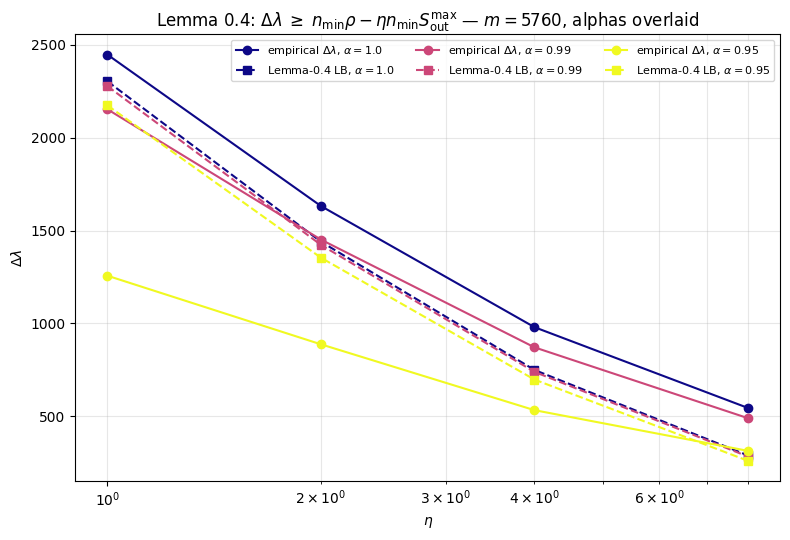

In [14]:
# Lemma-0.4 relation in the original "two curves vs eta" style — but now with
# one (empirical Δλ, lower bound) pair per alpha overlaid in the same panel.
GAP_VS_ETA_M      = max(M_VALUES)            # change to inspect a different total size
GAP_VS_ETA_ALPHAS = [1.0, 0.99, 0.95]         # alphas to overlay

cmap_alpha = plt.get_cmap("plasma")
alpha_to_color = {
    a: cmap_alpha(i / max(1, len(GAP_VS_ETA_ALPHAS) - 1))
    for i, a in enumerate(GAP_VS_ETA_ALPHAS)
}

fig, ax = plt.subplots(figsize=(8, 5.5))

for a in GAP_VS_ETA_ALPHAS:
    eta_axis  = []
    gap_emp_a = []
    gap_lb_a  = []
    for eta_target in ETA_VALUES:
        n1 = GAP_VS_ETA_M // (1 + int(eta_target))
        n2 = GAP_VS_ETA_M - n1
        S_a = build_decay_cbm_S(n1, n2, S_IN, S_OUT, alpha=a)
        L_a = compute_laplacian(S_a)
        eigvals_a, _ = compute_top_eigenpairs(L_a, k=3)

        eta_a   = imbalance_eta(n1, n2)
        nmin_a  = compute_n_min(n1, n2)
        rho_a   = structural_margin_rho(S_IN * a, S_OUT, S_OUT)
        eta_axis.append(eta_a)
        gap_emp_a.append(spectral_gap(eigvals_a))
        gap_lb_a.append(nmin_a * rho_a - eta_a * nmin_a * S_OUT)

    color = alpha_to_color[a]
    ax.plot(eta_axis, gap_emp_a, "-o", color=color,
            label=fr"empirical $\Delta\lambda$, $\alpha={a}$")
    ax.plot(eta_axis, gap_lb_a, "--s", color=color,
            label=fr"Lemma-0.4 LB, $\alpha={a}$")

ax.set_xscale("log")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\Delta\lambda$")
ax.set_title(
    fr"Lemma 0.4: $\Delta\lambda \;\geq\; n_{{\min}}\rho - \eta n_{{\min}} S_{{\mathrm{{out}}}}^{{\max}}$"
    fr" — $m={GAP_VS_ETA_M}$, alphas overlaid"
)
ax.legend(fontsize=8, loc="best", ncol=len(GAP_VS_ETA_ALPHAS))
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()
